In [1]:
import numpy as np
import matplotlib.pyplot as plt

1. Selecting a good random number generator

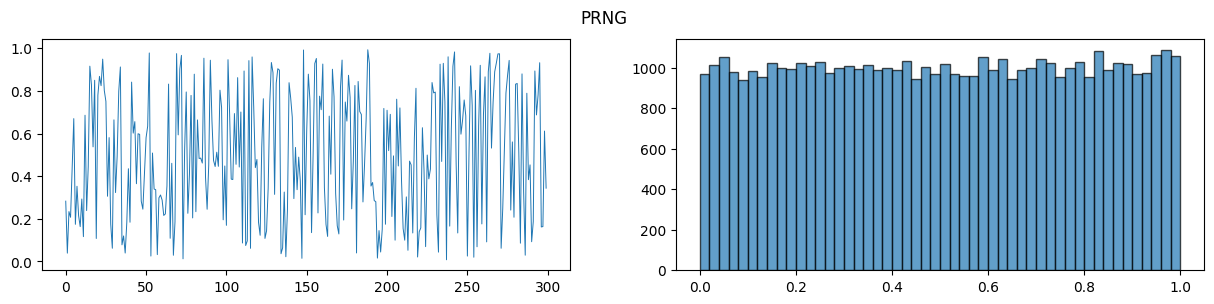

In [36]:
N = 50000
rng = np.random.default_rng()
prng1 = rng.uniform(low=0, high=1, size=N)

fig, ax = plt.subplots(1, 2, figsize=(15, 3))
ax[0].plot(prng1[:300], lw=0.7);
ax[1].hist(prng1, bins=50, edgecolor='k', alpha=0.7);
fig.suptitle('PRNG');

2. Creating a LCG

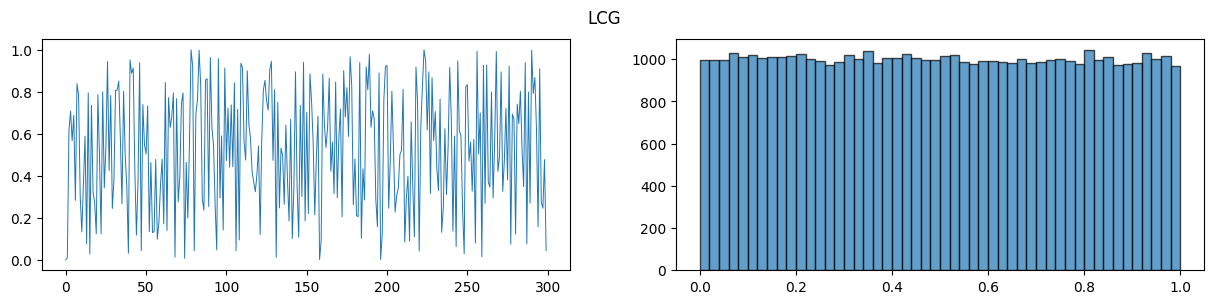

In [37]:
def lcg(k, X0, a, c, m):
    r = np.zeros(k)
    r[0] = X0/m
    for i in range(k-1):
        X1 = (a*X0+c)%m
        r[i+1] = X1/m
        X0 = X1
    return r

a = 63
c = 319
m = 65537

lcg1 = lcg(N, 5, a, c, m)

fig, ax = plt.subplots(1,2, figsize=(15, 3))
ax[0].plot(lcg1[:300], lw=0.7);
ax[1].hist(lcg1, bins=50, edgecolor='k', alpha=0.7);
fig.suptitle('LCG');

Visually, looks random enough. 

3. Check correlations by filling in a cube

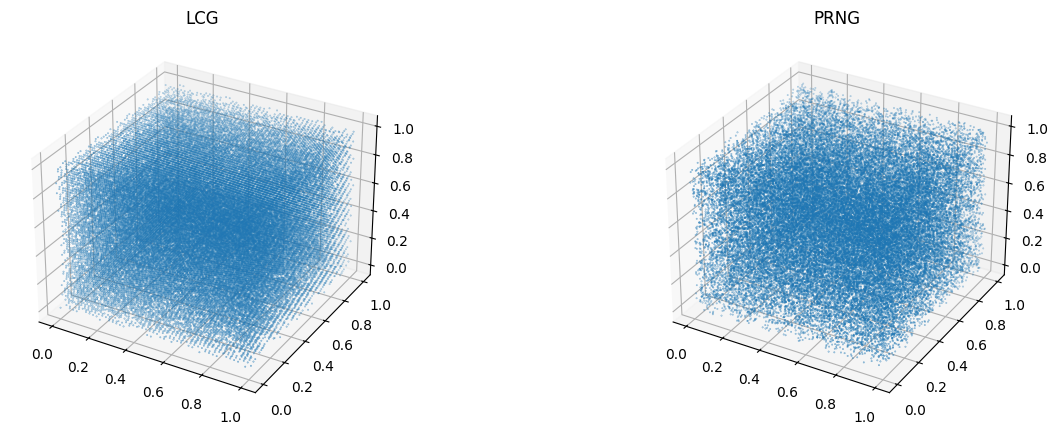

In [41]:
lcg2 = lcg(N, 70, a, c, m)
lcg3 = lcg(N, 555, a, c, m)

prng2 = rng.uniform(low=0, high=1, size=N)
prng3 = rng.uniform(low=0, high=1, size=N)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': '3d'})
ax[0].scatter(lcg1, lcg2, lcg3, s=0.1)
ax[0].set_title('LCG');
ax[1].scatter(prng1, prng2, prng3, s=0.1)
ax[1].set_title('PRNG');

Clearly there is some pattern in the LCG generated numbers as seen in the diagonal line artifacts

4. Check Autocorrelation

In [82]:
def ac(r, n):
    N = len(r)
    avg_x = r.mean()

    # if r is [1,2,3,4,5] and n=2 we want
    # 1/(5-2)* (1*3+2*4+3*5)
    # = 1/3 * [1,2,3]*[3,4,5]
    # = avg(r[:N-n]*r[n:])

    avg_xk_xkn = np.mean(r[:N-n]*r[n:])

    A = avg_xk_xkn-avg_x**2

    return(A)

lags = 5000
ac_prng = np.zeros(lags)
ac_lcg = np.zeros(lags)

for i in range(lags):
    ac_prng[i] = ac(prng1, i)
    ac_lcg[i] = ac(lcg1, i)
    

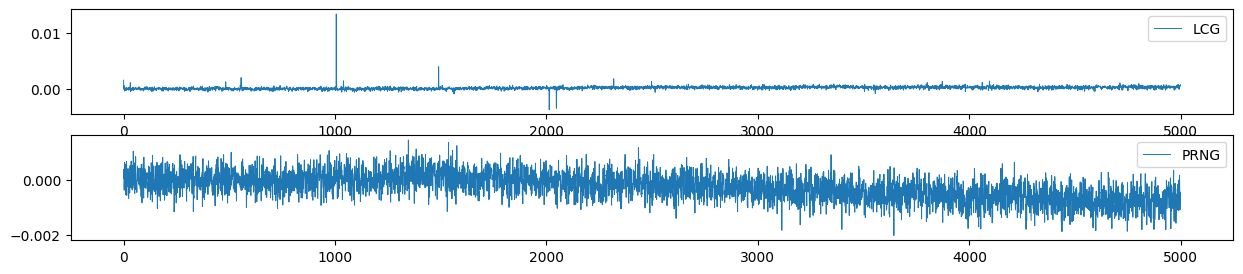

In [83]:
fig, ax = plt.subplots(2, 1, figsize=(15, 3))
ax[0].plot(ac_lcg[1:], lw=0.7, label='LCG')
ax[1].plot(ac_prng[1:], lw=0.7, label='PRNG')
ax[0].legend();
ax[1].legend();

Spikes in LCG suggest that there exist correlations between certain pairs of numbers as the autocorrelation function deviates from the mean for certain n. Let's do this for an even larger N.

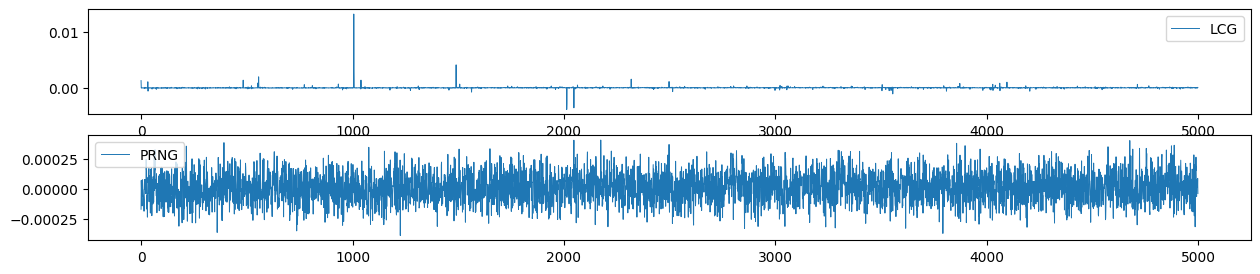

In [85]:
lcg4 = lcg(500000, 1010, a, c, m)
prng4 = rng.uniform(low=0, high=1, size=500000)

for i in range(lags):
    ac_prng[i] = ac(prng4, i)
    ac_lcg[i] = ac(lcg4, i)

fig, ax = plt.subplots(2, 1, figsize=(15, 3))
ax[0].plot(ac_lcg[1:], lw=0.7, label='LCG')
ax[1].plot(ac_prng[1:], lw=0.7, label='PRNG')
ax[0].legend();
ax[1].legend();

Spikes still exist for LCG. This means LCG shows detectable correlations for certain lags while the good PRNG does not. 